<a href="https://colab.research.google.com/github/IgorForceBR0202/linguagens_programacao/blob/main/Atividade_Matplotlib.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Contexto do Problema**

Você atua no time de Business Intelligence e precisa apresentar relatórios visuais sobre o desempenho de vendas de uma rede varejista. Você utilizará um conjunto de dados contendo o histórico de transações com valores, categorias, regiões, estados e datas para construir painéis analíticos claros e informativos.


In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Gerando dados sintéticos estruturados
np.random.seed(42)
n_registros = 120

datas = pd.date_range(start='2024-01-01', periods=n_registros, freq='D')
categorias = ['Eletronicos', 'Livros', 'Roupas', 'Automotivo']
estados = ['SP', 'RJ', 'MG', 'RS', 'BA']

dados = {
    'data': datas,
    'categoria': np.random.choice(categorias, size=n_registros),
    'estado': np.random.choice(estados, size=n_registros),
    'valor': np.random.uniform(50, 4500, size=n_registros).round(2),
    'quantidade': np.random.randint(1, 15, size=n_registros),
}

df = pd.DataFrame(dados)
df['valor_venda'] = (df['valor'] * np.random.uniform(0.9, 1.1, size=n_registros)).round(2)


## **PARTE 1 - 5**

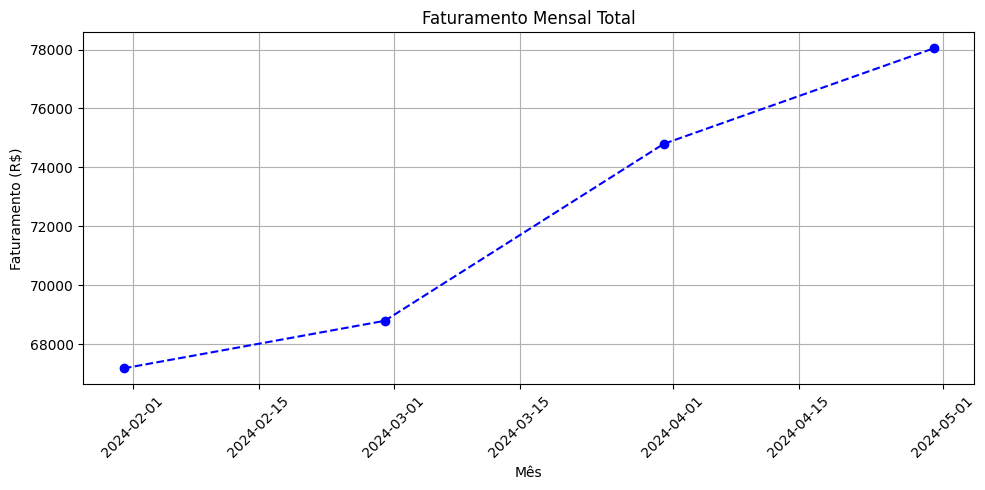

In [ ]:
faturamento_mensal = df.set_index('data')['valor_venda'].resample('ME').sum()

plt.figure(figsize=(10, 5))

plt.plot(
    faturamento_mensal.index,
    faturamento_mensal.values,
    marker='o',
    linestyle='--',
    color='blue'
)

plt.title('Faturamento Mensal Total')
plt.xlabel('Mês')
plt.ylabel('Faturamento (R$)')
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### **PARTE 1 - 6**

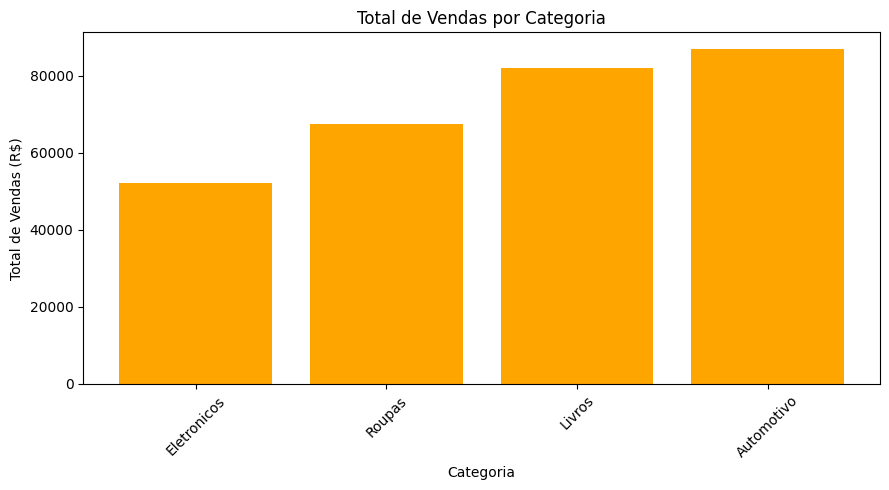

In [ ]:
# Total de vendas por categoria
vendas_categoria = df.groupby('categoria')['valor_venda'].sum()

# Ordenando do menor para o maior
vendas_categoria = vendas_categoria.sort_values()

plt.figure(figsize=(9, 5))

plt.bar(
    vendas_categoria.index,
    vendas_categoria.values,
    color='orange'
)

plt.title('Total de Vendas por Categoria')
plt.xlabel('Categoria')
plt.ylabel('Total de Vendas (R$)')

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

## **PARTE 1 - 7**

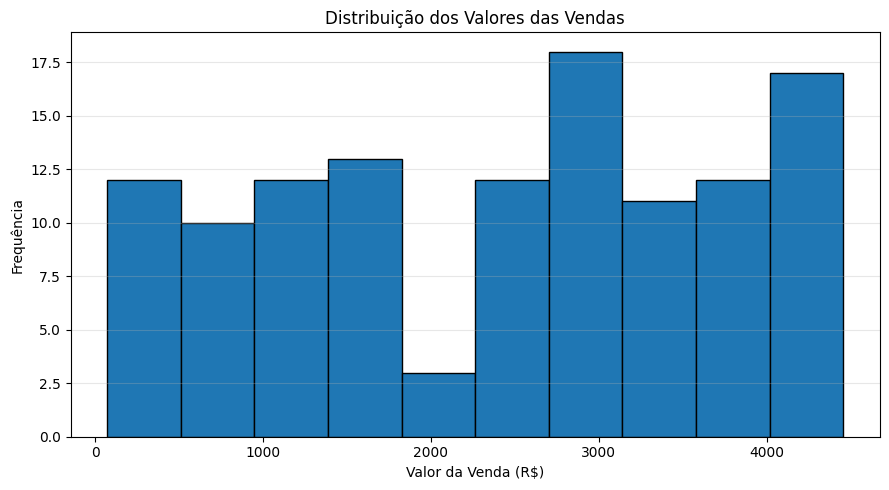

In [ ]:

plt.figure(figsize=(9, 5))

plt.hist(
    df['valor'],
    bins=10,
    edgecolor='black'
)

plt.title('Distribuição dos Valores das Vendas')
plt.xlabel('Valor da Venda (R$)')
plt.ylabel('Frequência')

plt.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

## **PARTE 2 - 4, 5 E 6**

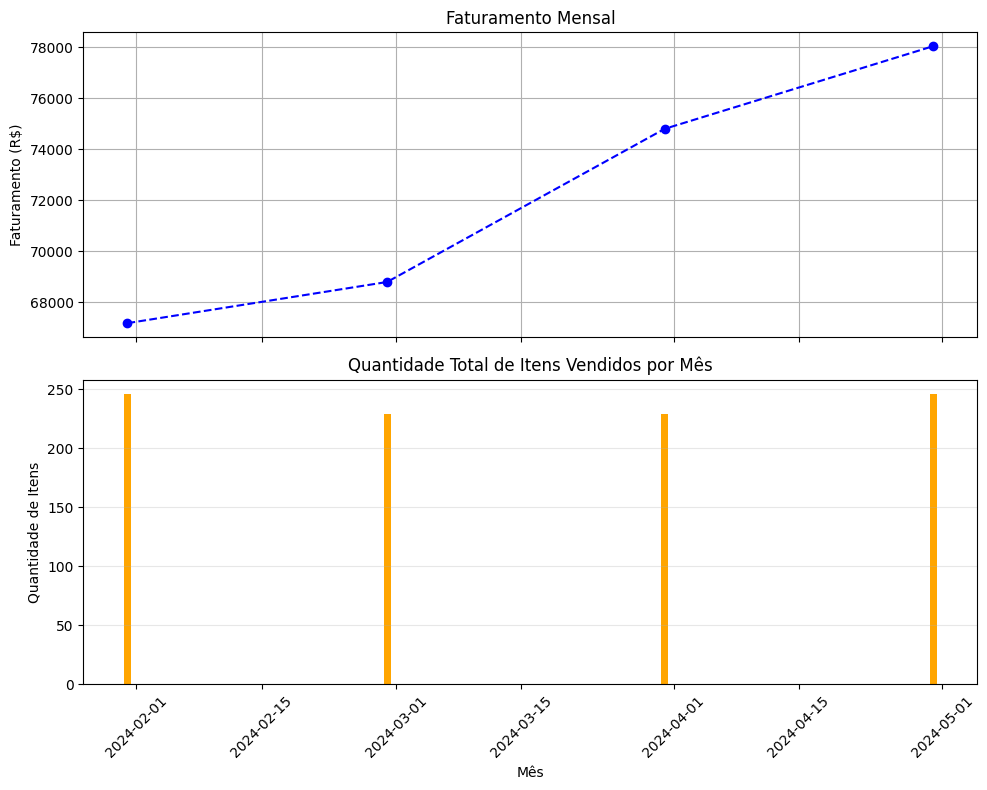

In [ ]:

faturamento_mensal = df.set_index('data')['valor_venda'].resample('ME').sum()

quantidade_mensal = df.set_index('data')['quantidade'].resample('ME').sum()

fig, (ax1, ax2) = plt.subplots(
    2, 1,
    sharex=True,
    figsize=(10, 8)
)

ax1.plot(
    faturamento_mensal.index,
    faturamento_mensal.values,
    marker='o',
    linestyle='--',
    color='blue'
)

ax1.set_title('Faturamento Mensal')
ax1.set_ylabel('Faturamento (R$)')
ax1.grid(True)

ax2.bar(
    quantidade_mensal.index,
    quantidade_mensal.values,
    color='orange'
)

ax2.set_title('Quantidade Total de Itens Vendidos por Mês')
ax2.set_xlabel('Mês')
ax2.set_ylabel('Quantidade de Itens')
ax2.grid(axis='y', alpha=0.3)


plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

## **PARTE 2 - 7**

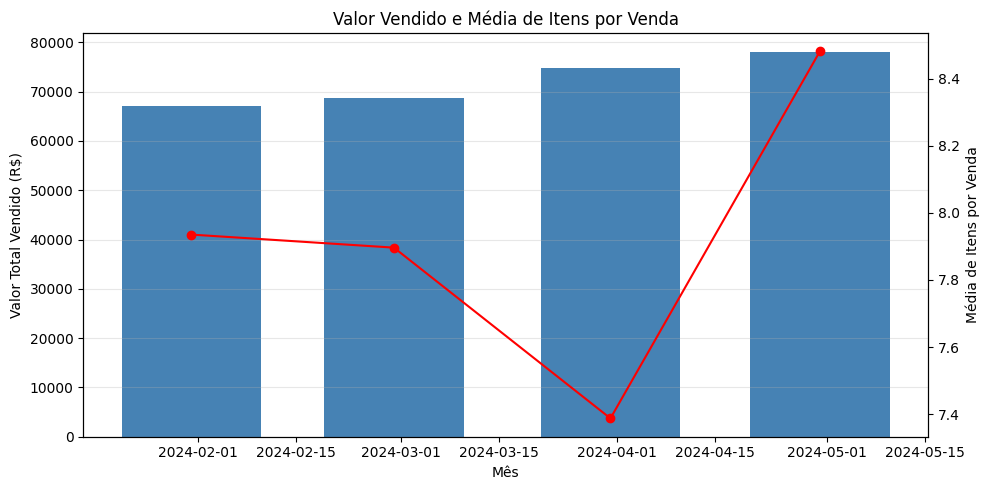

In [ ]:

# Valor total vendido por mês
valor_mensal = df.set_index('data')['valor_venda'].resample('ME').sum()

# Quantidade média de itens por venda por mês
media_itens_mensal = df.set_index('data')['quantidade'].resample('ME').mean()

# Criando a figura e o eixo principal
fig, ax = plt.subplots(figsize=(10, 5))

ax.bar(
    valor_mensal.index,
    valor_mensal.values,
    width=20,
    color='steelblue',
    label='Valor Total Vendido'
)

ax.set_xlabel('Mês')
ax.set_ylabel('Valor Total Vendido (R$)')
ax.set_title('Valor Vendido e Média de Itens por Venda')

ax.grid(axis='y', alpha=0.3)

ax2 = ax.twinx()

ax2.plot(
    media_itens_mensal.index,
    media_itens_mensal.values,
    marker='o',
    linestyle='-',
    color='red',
    label='Média de Itens por Venda'
)

ax2.set_ylabel('Média de Itens por Venda')

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

## **PARTE E - 8**

/tmp/ipykernel_7755/883545812.py:36: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


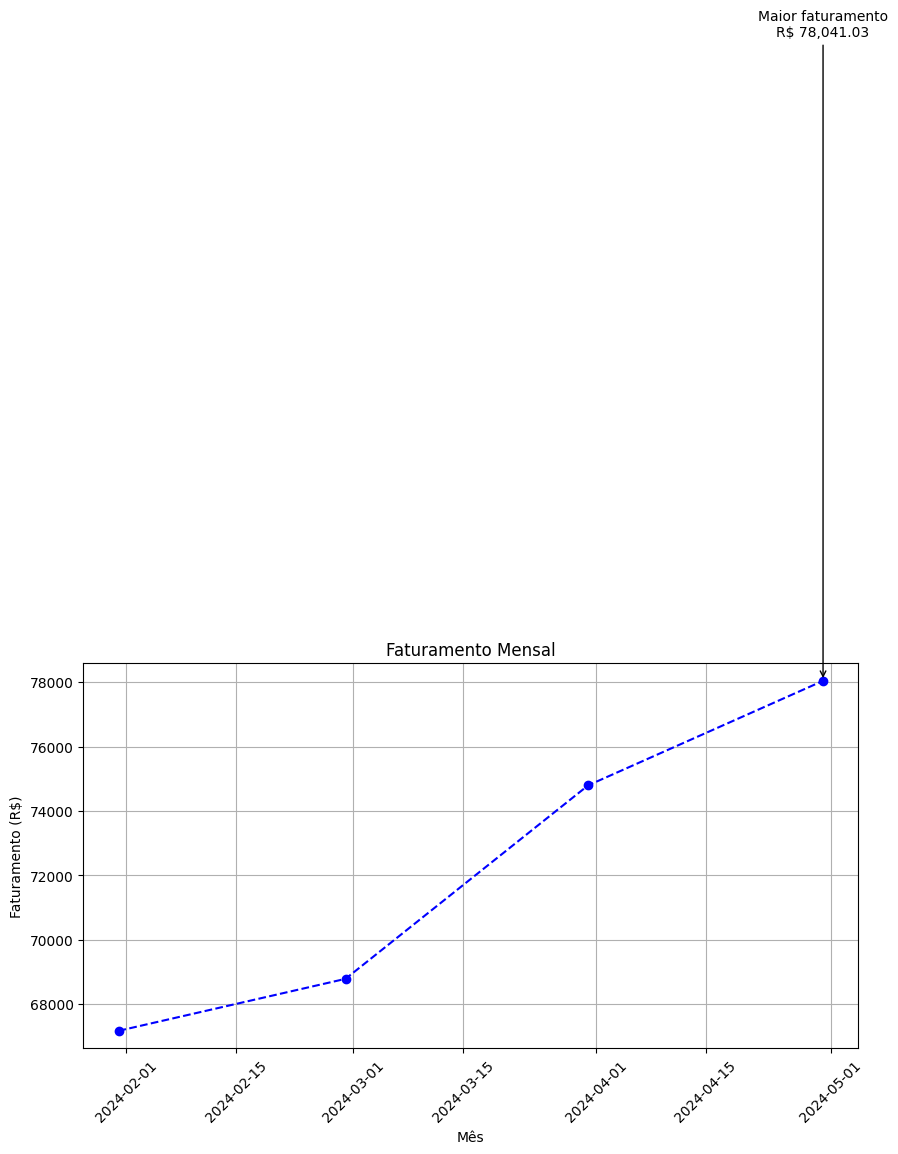

In [ ]:
# Faturamento mensal
faturamento_mensal = df.set_index('data')['valor_venda'].resample('ME').sum()

# Identificar o mês e o valor do maior faturamento
mes_maior = faturamento_mensal.idxmax()
valor_maior = faturamento_mensal.max()

# Criar o gráfico
fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(
    faturamento_mensal.index,
    faturamento_mensal.values,
    marker='o',
    linestyle='--',
    color='blue'
)

ax.set_title('Faturamento Mensal')
ax.set_xlabel('Mês')
ax.set_ylabel('Faturamento (R$)')
ax.grid(True)

# Anotação com seta apontando para o maior faturamento
ax.annotate(
    f'Maior faturamento\nR$ {valor_maior:,.2f}',
    xy=(mes_maior, valor_maior),
    xytext=(mes_maior, valor_maior + 20000),
    arrowprops=dict(
        arrowstyle='->'
    ),
    ha='center'
)

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()